# U-Net for Burned Area Mapping using NRBR — Part 1: Training on Large Areas.

This notebook trains a U-Net convolutional neural network to perform semantic segmentation of satellite imagery patches, distinguishing burned from unburned land using the NRBR spectral index. Data from Portugal and California is sourced from Google Earth Engine via TFRecord files.

## 1. Libraries to be used:

Imports all required libraries for data processing, deep learning (TensorFlow/Keras), visualization, and evaluation metrics.

In [ ]:
import os
import json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras import models
from keras import layers, Model
from keras.utils import to_categorical
from pathlib import Path
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

## 2. Set Random Seeds

Fixes random seeds across Python, NumPy, and TensorFlow to ensure reproducible results across runs.

In [ ]:
import random

SEED = 26
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

## 3. Connecting to Google Drive

Connects the Colab runtime to Google Drive to access training data, model weights, and output directories.

In [ ]:
# Connect to Drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Check GPU Availability

Verifies that a GPU is available in the runtime; raises an error if no GPU is detected to prevent slow CPU-only training.

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


Count the number of cores in your computer: Detects the number of CPU cores available in the runtime, useful for configuring parallel data loading.

In [ ]:
import multiprocessing

cores = multiprocessing.cpu_count()
print(f'Number of cores: {cores}')

Number of cores: 12


## 5. Collect TFRecord File Paths (NRBR)

Reading patches dowloaded from Earth Engine. Builds a list of all compressed TFRecord file paths for the NRBR variable, covering three training tiles from both Portugal and California.

**NRBR**

In [ ]:
# Portugal
path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1'
paths0 = glob(os.path.join(path, '*.gz'))

path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn2'
paths1 = glob(os.path.join(path, '*.gz'))

path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn3'
paths2 = glob(os.path.join(path, '*.gz'))

# California

path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/california/1_NRBR/trn1'
paths3 = glob(os.path.join(path, '*.gz'))

path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/california/1_NRBR/trn2'
paths4 = glob(os.path.join(path, '*.gz'))

path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/california/1_NRBR/trn3'
paths5 = glob(os.path.join(path, '*.gz'))

paths = paths0 + paths1 + paths2 + paths3 + paths4 + paths5
paths

['/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00000.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00001.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00002.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00003.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00004.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00005.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00006.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00007.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00008.tfrecord.gz',
 '/content/drive/MyDrive/00_PhD/papers/03/tfrecord/portugal/1_NRBR/trn1/Port-00009.tfrecord.gz',
 '/content/drive/MyDrive/00_Ph

## 6. Display Patch Metadata

Reads each tile's JSON mixer file from Google Earth Engine to display patch dimensions, patches per row, and total patch count per region.

In [ ]:
# Variable to be used
variable = '1_NRBR'

# Countries and tiles
countries = ['portugal', 'california']
tiles = ['trn1', 'trn2', 'trn3']
file_prefix = 'Port'
base_path = '/content/drive/MyDrive/00_PhD/papers/03/tfrecord'

# Store patch counts
patches = []

for country in countries:
    print(f'=== COUNTRY: {country.upper()} ===')
    for tile in tiles:
        print(f'--- Tile: {tile} ---')
        # Construct path to mixer JSON
        json_file = f'{base_path}/{country}/{variable}/{tile}/{file_prefix}-mixer.json'
        # Read JSON content from file
        json_text = !cat "{json_file}"
        mixer = json.loads(json_text.nlstr)
        # Print tile info
        print('Patch dimensions :', mixer.get('patchDimensions'))
        print('Patches per row  :', mixer.get('patchesPerRow'))
        print('Total patches    :', mixer.get('totalPatches'))
        print('')
        # Append number of patches for this tile
        patches.append(mixer.get('totalPatches'))

# Convert to array and print total
patches = np.array(patches)
print('TOTAL PATCHES TO BE TRAINED:', np.sum(patches))

=== COUNTRY: PORTUGAL ===
--- Tile: trn1 ---
Patch dimensions : [256, 256]
Patches per row  : 51
Total patches    : 1989

--- Tile: trn2 ---
Patch dimensions : [256, 256]
Patches per row  : 52
Total patches    : 2028

--- Tile: trn3 ---
Patch dimensions : [256, 256]
Patches per row  : 51
Total patches    : 1989

=== COUNTRY: CALIFORNIA ===
--- Tile: trn1 ---
Patch dimensions : [256, 256]
Patches per row  : 49
Total patches    : 1911

--- Tile: trn2 ---
Patch dimensions : [256, 256]
Patches per row  : 51
Total patches    : 1989

--- Tile: trn3 ---
Patch dimensions : [256, 256]
Patches per row  : 51
Total patches    : 1989

TOTAL PATCHES TO BE TRAINED: 11895


## 7. Set Patch Dimensions

Defines the fixed spatial resolution of each image patch (256×256 pixels) used throughout training.

In [ ]:
# Get relevant info from the JSON mixer file.
patch_width = 256
patch_height = 256
patch_dimensions_flat = [patch_width, patch_height]
patch_dimensions_flat

[256, 256]

## 8. Define TFRecord Feature Schema

Creates the parsing dictionary that maps band names (NRBRcombined, label) to their expected TensorFlow tensor shapes and data types.

In [ ]:
bands = ['NRBRcombined', 'label'] # 'dVH'
image_columns = [tf.io.FixedLenFeature(shape=patch_dimensions_flat, dtype=tf.float32) for k in bands]

#bands += ['classes']
image_columns += [tf.io.FixedLenFeature(shape=patch_dimensions_flat, dtype=tf.int64)]

# Parsing dictionary
image_features_dict = dict(zip(bands, image_columns))
image_features_dict

{'NRBRcombined': FixedLenFeature(shape=[256, 256], dtype=tf.float32, default_value=None),
 'label': FixedLenFeature(shape=[256, 256], dtype=tf.float32, default_value=None)}

## 9. Define TFRecord Parsing Function

Wraps the feature dictionary into a function that decodes individual TFRecord examples during dataset loading.

In [ ]:
# Parsing function
def parse_image(example_proto):
  return tf.io.parse_single_example(example_proto, image_features_dict)

## 10. Load Patches into Arrays

Reads all TFRecord files, extracts image and label patches, and filters out invalid patches (those with more than 40% zero or NaN pixels) before storing valid ones in memory. In this step, patches downloaded for GEE will be saved as arrays with shape (a, b, c, d). Where a represents the number of patches, b and c represent the patch dimension and d represents the number of bands for each patch.

In [ ]:
# First, initialize patch containers
bands = 1  # number of bands
array_image = np.zeros((patch_width, patch_height, bands))  # rows, columns, bands
array_label = np.zeros((patch_width, patch_height, 1))       # rows, columns, label channel

Xl = []
yl = []

bands_image = ['NRBRcombined']
bands_label = ['label']

# Function to check if a patch contains enough valid data
def is_valid_patch(patch, threshold = 0.6):
    """
    Returns True if more than 'threshold' proportion of pixels are
    different from 0 and not NaN.
    """
    total_pixels = patch.size
    valid_pixels = np.sum((patch != 0) & (~np.isnan(patch)))
    return (valid_pixels / total_pixels) > threshold

# Iterate over all TFRecord files
for file in np.arange(len(paths)):
    image_dataset = tf.data.TFRecordDataset(str(paths[file]), compression_type='GZIP')
    ds = image_dataset.map(parse_image, num_parallel_calls = 10)
    arr = list(ds.as_numpy_iterator())

    for j in range(len(arr)):
        names = arr[j]

        # Build the image patch
        for i, bnames in enumerate(bands_image):
            array_image[:, :, i] = names[bnames]

        # Keep only valid patches (at least 80% valid pixels)
        if is_valid_patch(array_image):
            Xl.append(array_image.copy())

            # Build the corresponding label patch
            for i, bnames in enumerate(bands_label):
                array_label[:, :, i] = names[bnames]
            yl.append(array_label.copy())

Then, patches can be converted to array. So, in total we have 3978 patches with 256*256 for both image and labeling data.

In [ ]:
X = np.array(Xl)
y = np.array(yl)

# print basic details
print('Input features shape:', X.shape)
print('\nInput labels shape:', y.shape)

Input features shape: (10569, 256, 256, 1)

Input labels shape: (10569, 256, 256, 1)


## 11. Handle NaN Values

Dealing with NaN values. Replaces any remaining NaN values in both image and label arrays with zeros to ensure clean input to the model.

In [ ]:
# replacing nan -> 0
X[np.isnan(X)] = 0

# replacing nan -> 0
y[np.isnan(y)] = 0

## 12. Normalize Input Data

Applies StandardScaler normalization independently to each spectral band, centering and scaling pixel values for stable model training.

In [ ]:
# normalizing data
for i in range(X.shape[3]):
    band = X[:, :, :, i]
    band_normalized = StandardScaler().fit_transform(band.reshape(-1, 1)).reshape(X.shape[0], 256, 256)
    X[:, :, :, i] = band_normalized

# Verifying the new dimensions (shape)
print("Normalized array:", X.shape)

Normalized array: (10569, 256, 256, 1)


Check for Infinite Values: Validates that neither the image array nor the label array contains any infinite values after normalization.

In [ ]:
# Verificar valores infinitos
print(f"Valores infinitos en X: {np.isinf(X).sum()}")
print(f"Valores infinitos en y: {np.isinf(y).sum()}")

Valores infinitos en X: 0
Valores infinitos en y: 0


Prints the minimum and maximum values present in the label array to confirm the expected class range.

In [ ]:
# details
print('Values in input features, min: %d & max: %d' % (np.min(y), np.max(y)))

Values in input features, min: 0 & max: 1


## 13. Train/Test Split

Splits the dataset into 70% training and 30% testing subsets using stratified shuffling with a fixed random seed.

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size = 0.7, random_state = SEED, shuffle=True)

# veamos los datos
Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((7398, 256, 256, 1),
 (3171, 256, 256, 1),
 (7398, 256, 256, 1),
 (3171, 256, 256, 1))

## 14. One-Hot Encode Labels

Converts integer class labels into one-hot categorical vectors for both training and testing sets, as required by the softmax output layer.

In [ ]:
n_classes = len(np.unique(y))
ytrain_catego = to_categorical(ytrain, num_classes = n_classes)
ytest_catego = to_categorical(ytest, num_classes = n_classes)

# veamos los datos
Xtrain.shape, Xtest.shape, ytrain_catego.shape, ytest_catego.shape

((7398, 256, 256, 1),
 (3171, 256, 256, 1),
 (7398, 256, 256, 2),
 (3171, 256, 256, 2))

## 15. Define U-Net Architecture

Implements the U-Net model with a 4-level encoder (downsampling), a bottleneck, and a symmetric decoder (upsampling) with skip connections for pixel-wise classification.

In [ ]:
# Number of bands
bands = 1

from tensorflow.keras import layers, Model

def unet_model(num_classes=2, img_height=256, img_width=256, img_channels=bands):
    # Entrada del modelo
    inputs = layers.Input((img_height, img_width, img_channels))

    # Down-sampling (Encoder)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)

    # Bottleneck
    conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv5)

    # Up-sampling (Decoder)
    up6 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv5)
    up6 = layers.concatenate([up6, conv4])
    conv6 = layers.Conv2D(256, 3, activation='relu', padding='same')(up6)
    conv6 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv6)

    up7 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv6)
    up7 = layers.concatenate([up7, conv3])
    conv7 = layers.Conv2D(128, 3, activation='relu', padding='same')(up7)
    conv7 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv7)

    up8 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv7)
    up8 = layers.concatenate([up8, conv2])
    conv8 = layers.Conv2D(64, 3, activation='relu', padding='same')(up8)
    conv8 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv8)

    up9 = layers.Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv8)
    up9 = layers.concatenate([up9, conv1])
    conv9 = layers.Conv2D(32, 3, activation='relu', padding='same')(up9)
    conv9 = layers.Conv2D(32, 3, activation='relu', padding='same')(conv9)

    # Capa de salida con dtype float32 obligatorio en mixed precision
    if num_classes == 1:
        outputs = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32')(conv9)
    else:
        outputs = layers.Conv2D(num_classes, 1, activation='softmax', dtype='float32')(conv9)

    # Evita el warning: siempre pasar inputs como lista
    model = Model(inputs=[inputs], outputs=[outputs])
    return model

## 16. Define Dice Loss and Combined Loss

Implements Dice Loss to handle class imbalance and combines it with Categorical Cross-Entropy into a single composite loss function used during training.

In [ ]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

# Dice Loss function
def dice_loss(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=[1, 2, 3])
    denominator = tf.reduce_sum(y_true_f + y_pred_f, axis=[1, 2, 3])

    dice = (2. * intersection + smooth) / (denominator + smooth)
    return 1 - tf.reduce_mean(dice)

# Final combined loss: CCE + Dice Loss
def combined_loss(y_true, y_pred):
    cce = CategoricalCrossentropy()(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return cce + d_loss

## 17. Define IoU and Mean IoU Metrics

Defines custom IoU metrics to measure overlap between predicted and ground-truth burned areas, evaluated per class and averaged across both classes.

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def iou(y_true, y_pred, smooth=1e-4):
    # Convert one-hot to labels
    y_pred = tf.argmax(y_pred, axis=-1)
    y_true = tf.argmax(y_true, axis=-1)

    # Extract class 1 (burned)
    y_pred_class1 = tf.cast(tf.equal(y_pred, 1), tf.float32)
    y_true_class1 = tf.cast(tf.equal(y_true, 1), tf.float32)

    intersection = K.sum(y_pred_class1 * y_true_class1, axis=[1, 2])
    union = K.sum(y_pred_class1, axis=[1, 2]) + K.sum(y_true_class1, axis=[1, 2]) - intersection

    iou = (intersection + smooth) / (union + smooth)
    return K.mean(iou)

def mean_iou(y_true, y_pred, smooth=1e-4):
    y_true = tf.argmax(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    ious = []
    for c in [0, 1]:
        y_true_c = tf.cast(tf.equal(y_true, c), tf.float32)
        y_pred_c = tf.cast(tf.equal(y_pred, c), tf.float32)

        intersection = tf.reduce_sum(y_true_c * y_pred_c, axis=[1, 2])
        union = tf.reduce_sum(y_true_c + y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        ious.append(iou)

    return tf.reduce_mean(tf.stack(ious, axis=0))

## 18. Compile Model and Save Initial Weights

Instantiates the U-Net, compiles it with Adam optimizer and the combined loss, saves the initial random weights, and prints the model summary.

In [ ]:
from tensorflow.keras.optimizers import Adam

# calling the model
model = unet_model(num_classes = 2, img_height = 256, img_width = 256, img_channels = bands)
model.compile(optimizer = 'adam',
              loss = combined_loss,
              metrics = ['accuracy', mean_iou, iou])
# Save the initial weights
model.save_weights("/content/drive/MyDrive/00_PhD/papers/03/weights/NRBR_initial2.weights.h5")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_3[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_8[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,759,554 (29.60 MB)

 Trainable params: 7,759,554 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

Prints the expected input tensor shape to confirm the model accepts single-band 256×256 patches.

In [ ]:
# input model
model.input_shape

(None, 256, 256, 1)

Re-instantiates the model and loads previously saved weights, allowing training to resume or a specific initialization to be reused.

In [ ]:
# calling the model
model = unet_model(num_classes = 2, img_height = 256, img_width = 256, img_channels = bands)
model.compile(optimizer = 'adam',
              loss = combined_loss,
              metrics = ['accuracy', mean_iou, iou])
model.load_weights("/content/drive/MyDrive/00_PhD/papers/03/weights/NRBR_initial.weights2.h5")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 4 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Verifies the model's input shape is unchanged after reloading weights.

In [ ]:
# input model
model.input_shape

(None, 256, 256, 1)

## 19. Train Model with Early Stopping

Trains the U-Net for up to 300 epochs with batch size 8, using ModelCheckpoint to save the best model by validation IoU and EarlyStopping to halt if no improvement is seen for 15 epochs.

In [ ]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model

# === Define model output directory and filename ===
variable_name = "NRBR2"
model_dir = f"/content/drive/MyDrive/00_PhD/papers/03/models"

best_model_path = os.path.join(model_dir, f"model_{variable_name.lower()}.keras")

# === Callbacks ===

# Save the model with the best validation IoU
checkpoint_cb = ModelCheckpoint(
    filepath=best_model_path,     # Save to custom path
    monitor='val_iou',                # Metric to monitor
    save_best_only=True,          # Save only the best model
    mode='max',                   # Because higher IoU is better
    verbose=1
)

# Stop training if validation IoU doesn't improve for N epochs
early_stopping_cb = EarlyStopping(
    monitor='val_iou',
    patience=15,
    mode='max',
    restore_best_weights=True,    # Restore best weights into current model
    verbose=1
)

# === Model Training ===

history = model.fit(
    Xtrain,
    ytrain_catego,
    epochs = 300,
    batch_size = 8,
    validation_data = (Xtest, ytest_catego),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

# Optional: print path to saved model
print(f"Best model saved at: {best_model_path}")

Epoch 1/300


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 1))
  warnings.warn(msg)


925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8585 - iou: 0.4595 - loss: 0.5888 - mean_iou: 0.6323
Epoch 1: val_iou improved from -inf to 0.60250, saving model to /content/drive/MyDrive/00_PhD/papers/03/models/model_nrbr2.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 51s 42ms/step - accuracy: 0.8586 - iou: 0.4596 - loss: 0.5887 - mean_iou: 0.6323 - val_accuracy: 0.9049 - val_iou: 0.6025 - val_loss: 0.3923 - val_mean_iou: 0.7069
Epoch 2/300
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9058 - iou: 0.6563 - loss: 0.4019 - mean_iou: 0.7383
Epoch 2: val_iou improved from 0.60250 to 0.65091, saving model to /content/drive/MyDrive/00_PhD/papers/03/models/model_nrbr2.keras
925/925 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.9058 - iou: 0.6563 - loss: 0.4019 - mean_iou: 0.7383 - val_accuracy: 0.8950 - val_iou: 0.6509 - val_loss: 0.5174 - val_mean_iou: 0.7404
Epoch 3/300
925/925 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9054 - iou: 0.6428 - loss: 0.4050 - mean_iou: 0.7322
Ep

Identifies and prints the epoch at which the highest validation IoU was achieved during training.

In [ ]:
# Get the epoch index (starting from 0) where validation IoU was highest
best_epoch = np.argmax(history.history['val_iou'])
best_iou = history.history['val_iou'][best_epoch]

print(f"Best validation IoU: {best_iou:.4f} at epoch {best_epoch}")

Best validation IoU: 0.7873 at epoch 10


Displays all metric names recorded in the training history, useful for selecting what to plot or export.

In [ ]:
print(history.history.keys())

dict_keys(['accuracy', 'iou', 'loss', 'mean_iou', 'val_accuracy', 'val_iou', 'val_loss', 'val_mean_iou'])


## 20. Plot Training IoU and Loss

Renders a dual-axis chart showing training IoU and training loss across epochs to visualize learning progress.

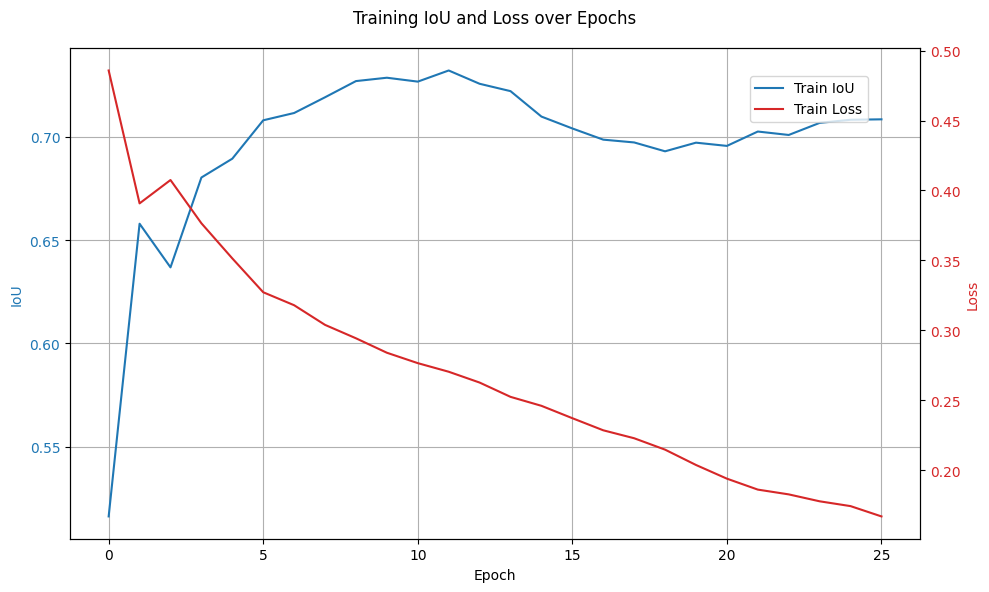

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Plot IoU ---
color_iou = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('IoU', color=color_iou)
ax1.plot(history.history['iou'], color=color_iou, label='Train IoU')
# ax1.plot(history.history['val_iou'], '--', color='tab:cyan', label='Val IoU')
ax1.tick_params(axis='y', labelcolor=color_iou)
ax1.grid(True)

# --- Create second y-axis for Loss ---
ax2 = ax1.twinx()
color_loss = 'tab:red'
ax2.set_ylabel('Loss', color=color_loss)
ax2.plot(history.history['loss'], color=color_loss, label='Train Loss')
# ax2.plot(history.history['val_loss'], '--', color='tab:pink', label='Val Loss')
ax2.tick_params(axis='y', labelcolor=color_loss)

# --- Title and legend ---
fig.suptitle('Training IoU and Loss over Epochs')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.show()

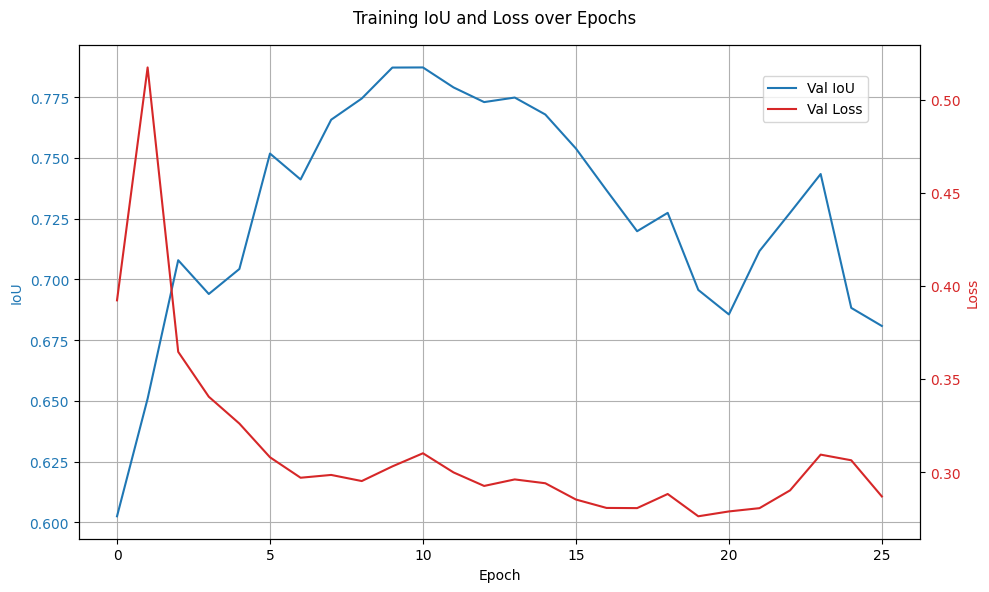

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Plot IoU ---
color_iou = 'tab:blue'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('IoU', color=color_iou)
ax1.plot(history.history['val_iou'], color=color_iou, label='Val IoU')
# ax1.plot(history.history['val_iou'], '--', color='tab:cyan', label='Val IoU')
ax1.tick_params(axis='y', labelcolor=color_iou)
ax1.grid(True)

# --- Create second y-axis for Loss ---
ax2 = ax1.twinx()
color_loss = 'tab:red'
ax2.set_ylabel('Loss', color=color_loss)
ax2.plot(history.history['val_loss'], color=color_loss, label='Val Loss')
# ax2.plot(history.history['val_loss'], '--', color='tab:pink', label='Val Loss')
ax2.tick_params(axis='y', labelcolor=color_loss)

# --- Title and legend ---
fig.suptitle('Training IoU and Loss over Epochs')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.show()

## 21. Save Training Metrics to CSV

Exports all training and validation metrics per epoch into a CSV file saved to Google Drive for later analysis.

In [ ]:
import pandas as pd

# Create a DataFrame with all the metrics
metrics_df = pd.DataFrame({
    'epoch': list(range(1, len(history.history['loss']) + 1)),
    'train_loss': history.history['loss'],
    'accuracy': history.history['accuracy'],
    'train_iou': history.history['iou'],
    'mean_iou': history.history['mean_iou'],
    'val_loss': history.history['val_loss'],
    'val_accuracy': history.history['val_accuracy'],
    'val_iou': history.history['val_iou'],
    'val_mean_iou': history.history['val_mean_iou']
})

# Save it to CSV (you can change the path to Google Drive if needed)
metrics_df.to_csv('/content/drive/MyDrive/00_PhD/papers/03/dataset/csv/metrics_history_nrbr2.csv', index=False)

## 22. (Optional) Reload Saved Model

Reload a fresh Keras model from the ```.keras``` zip archive:

In [ ]:
#model = tf.keras.models.load_model('/content/drive/MyDrive/00_PhD/models/Portugal/unet_model_6tiles_14112024.keras')

# Show the model architecture
#model.summary()

Prints the model's input shape to verify the loaded model is correctly configured.

In [ ]:
# expected dimensions for input
model.input_shape

(None, 512, 512, 1)

## 23. Accuracy assessment of burned area mapping

Runs the trained U-Net on the test set and converts softmax probability outputs into hard class predictions using argmax.

In [ ]:
class_names = ['unburned', 'burned']

# predicting
y_pred = model.predict(Xtest)
y_pred_argmax=np.argmax(y_pred, axis = 3)
y_test_argmax=np.argmax(ytest_catego, axis = 3)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 512, 512, 1))
  warnings.warn(msg)


18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 388ms/step


1. *Overall Accuracy*: Computes the pixel-level overall accuracy of the model's predictions on the test set.

In [ ]:
y_test_argmax = y_test_argmax.flatten()
y_pred_argmax = y_pred_argmax.flatten()

In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(accuracy_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.9963


2. *Recall*: Computes recall (sensitivity) for the burned class, measuring how well the model detects actual burned pixels.

In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(recall_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.9907


3. *Precision*: Computes precision for the burned class, measuring how many of the predicted burned pixels are truly burned.


In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(precision_score(y_test_argmax, y_pred_argmax)))

precision obtenida: 0.9844


4. *F1-score*: Computes the F1-score, the harmonic mean of precision and recall, as a balanced performance metric.

In [ ]:
# Overall accuracy obtained
print("precision obtenida: {:.4f}".format(f1_score(y_test_argmax, y_pred_argmax)))

5. *IoU (Intersection-Over-Union)*

It is a common evaluation metric for semantic image segmentation. How does it work?

confusion matrix = [(1, 1), (1, 1)]

sum_row = (2, 2), sum_col = (2, 2), true_positives = (1, 1)

iou = true_positives/(sum_row + sum_col - true_positives)

iou = [0.33, 0.33]

- https://www.tensorflow.org/api_docs/python/tf/keras/metrics/IoU

In [ ]:
#Using built in keras function for IoU
from keras.metrics import MeanIoU
n_classes = len(np.unique(y))
IOU_keras = MeanIoU(num_classes=n_classes)
IOU_keras.update_state(y_test_argmax, y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

Mean IoU = 0.9855136


Confusion matrix: Generates the raw confusion matrix comparing predicted labels to ground-truth labels across all test pixels.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_argmax, y_pred_argmax)

array([[122319274,    334475],
       [   197711,  21065596]])

Let's plot Confusion Matriz:

Defines a reusable helper function that renders a styled, annotated confusion matrix using Matplotlib.



In [ ]:
def plotConfusionMatrix(y_test , y_pred , text_size = 12, classes = None , ax = None):

  if ax is None:
        ax = plt.gca() # get current axes

  # Create the confusion matrix from sklearn
  cm = confusion_matrix(y_test , y_pred)
  threshold = (cm.max() + cm.min()) /2

  # Number of clases
  n_classes = cm.shape[0]

  # Drawing the matrix plot
  b = ax.matshow(cm , cmap = plt.cm.Blues)
  bar = plt.colorbar(b)

  # Set labels to be classes
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label axes
  ax.set(title ='Confusion Matrix', xlabel = 'Ground-truth' ,
         ylabel = 'Prediction', xticks = np.arange(n_classes),
         yticks = range(n_classes), xticklabels = labels , yticklabels = labels)
  # Set the xaxis labels to bottom
  ax.xaxis.set_label_position('bottom')
  ax.xaxis.tick_bottom()

  # Adjust the label size
  ax.yaxis.label.set_size(text_size)
  ax.xaxis.label.set_size(text_size)
  ax.title.set_size(text_size)
  ax.grid(False)

  # Plot the text on each cell
  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      ax.text(i,j, f'{cm[i,j]}',
               horizontalalignment = 'center' ,
               color = 'white' if cm[i , j] > threshold else 'black',
               size = text_size)

Visualize Confusion Matrix

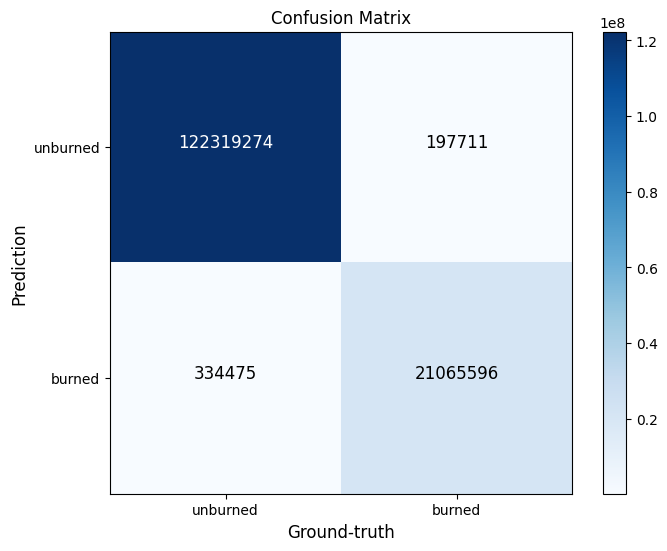

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
plotConfusionMatrix(y_test_argmax.flatten(), y_pred_argmax.flatten(), classes = class_names)

## 24. Predict on a Single Random Patch

Selects a random test patch, runs it through the model, and extracts the predicted segmentation mask for visual inspection.

In [ ]:
import random
test_img_number = random.randint(0, len(Xtest))
test_img = Xtest[test_img_number]
ground_truth = y_test_argmax[test_img_number]
test_img_input=np.expand_dims(test_img, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


## 25. Visualize Ground Truth vs. Prediction

Displays side-by-side plots of the reference label and the model's predicted mask for the selected test patch.

In [ ]:
# histogram with percentiles
def hist_percentile(arr_rgb):
  p10 = np.nanpercentile(arr_rgb, 10) # percentile10
  p90 = np.nanpercentile(arr_rgb, 90) # percentile90
  clipped_arr = np.clip(arr_rgb, p10, p90)
  arr_rgb_norm = (clipped_arr - p10)/(p90 - p10)
  return arr_rgb_norm

orig_map = plt.colormaps['Greys']
reversed_map = orig_map.reversed()

fig, ax = plt.subplots(1, 2, figsize = (12,8))

#rgb_patch = hist_percentile(np.dstack((test_img[:,:,9], test_img[:,:,6], test_img[:,:,2])))
#ax[0].imshow(rgb_patch)
#ax[0].set_title('Landsat-8 patch (64, 64)')
ax[0].imshow(ground_truth, cmap = reversed_map)
ax[0].set_title('Testing Label')
ax[1].imshow(predicted_img, cmap = reversed_map)
ax[1].set_title('Prediction on test image')
plt.show()